In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [46]:
df = pd.read_csv(r"C:\Users\Abhishek Verma\Downloads\Churn_Modelling_with_nulls.csv")

In [47]:
df1 = df.copy()

In [48]:
df1.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602.0,Hargrave,619.0,France,Female,NaN,2.0,0.00,1.0,1.0,1.0,101348.88,1.0
1,2,15647311.0,Hill,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0
2,3,15619304.0,Onio,502.0,France,Female,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0
3,4,15701354.0,Boni,699.0,France,Female,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0
4,5,15737888.0,Mitchell,850.0,Spain,Female,43.0,NaN,125510.82,1.0,1.0,1.0,79084.10,0.0


In [49]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       9505 non-null   float64
 2   Surname          9467 non-null   object 
 3   CreditScore      9484 non-null   float64
 4   Geography        9498 non-null   object 
 5   Gender           9519 non-null   object 
 6   Age              9481 non-null   float64
 7   Tenure           9486 non-null   float64
 8   Balance          9503 non-null   float64
 9   NumOfProducts    9514 non-null   float64
 10  HasCrCard        9503 non-null   float64
 11  IsActiveMember   9503 non-null   float64
 12  EstimatedSalary  9519 non-null   float64
 13  Exited           9522 non-null   float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.1+ MB


In [50]:
df1.isnull().sum()

RowNumber            0
CustomerId         495
Surname            533
CreditScore        516
Geography          502
Gender             481
Age                519
Tenure             514
Balance            497
NumOfProducts      486
HasCrCard          497
IsActiveMember     497
EstimatedSalary    481
Exited             478
dtype: int64

In [51]:
df1["CreditScore"] = df1["CreditScore"].fillna(df1["CreditScore"].mean())

df1["Age"] = df1["Age"].fillna(df1["Age"].mean())

df1["Balance"] = df1["Balance"].fillna(df1["Balance"].mean())

df1["EstimatedSalary"] = df1["EstimatedSalary"].fillna(df1["EstimatedSalary"].mean())

In [52]:
df1["Tenure"] = df1["Tenure"].fillna(df1["Tenure"].mode()[0])

df1["NumOfProducts"] = df1["NumOfProducts"].fillna(df1["NumOfProducts"].mode()[0])

df1["HasCrCard"] = df1["HasCrCard"].fillna(df1["HasCrCard"].mode()[0])

df1["IsActiveMember"] = df1["IsActiveMember"].fillna(df1["IsActiveMember"].mode()[0])

df1["Gender"] = df1["Gender"].fillna(df1["Gender"].mode()[0])

df1["Geography"] = df1["Geography"].fillna(df1["Geography"].mode()[0])

In [53]:
df1.isnull().sum()

RowNumber            0
CustomerId         495
Surname            533
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited             478
dtype: int64

In [54]:
df1 = df1.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [55]:
df1.isnull().sum()

CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited             478
dtype: int64

In [56]:
le = LabelEncoder()

In [57]:
df1["Gender"] = le.fit_transform(df1["Gender"])
df1["Geography"] = le.fit_transform(df1["Geography"])

In [58]:
df1["Exited"].isnull().sum()

np.int64(478)

In [59]:
df1 = df1.dropna(subset=["Exited"])

In [60]:
df1["Exited"].isnull().sum()

np.int64(0)

In [61]:
X = df1.drop("Exited", axis=1)
y = df1["Exited"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
df1.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [64]:
y.isnull().sum()

np.int64(0)

In [65]:
df1["Exited"].isnull().sum()

np.int64(0)

In [66]:
df1["Exited"].value_counts(dropna=False)

Exited
0.0    7595
1.0    1927
Name: count, dtype: int64

In [67]:
X_train.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

In [68]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

P:\python\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [69]:
from sklearn.preprocessing import StandardScaler

In [70]:
scaler = StandardScaler()

In [71]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [72]:
y_pred = model.predict(X_test)

P:\python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [73]:
from sklearn.metrics import accuracy_score

In [74]:
accuracy = accuracy_score(y_test, y_pred)

In [75]:
print("Accuracy =", accuracy)

Accuracy = 0.6356955380577428


In [76]:
from sklearn.metrics import confusion_matrix

In [77]:
cm = confusion_matrix(y_test, y_pred)

In [78]:
print(cm)

[[996 516]
 [178 215]]


In [79]:
from sklearn.metrics import classification_report

In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.85      0.66      0.74      1512
         1.0       0.29      0.55      0.38       393

    accuracy                           0.64      1905
   macro avg       0.57      0.60      0.56      1905
weighted avg       0.73      0.64      0.67      1905



In [81]:
new_customer = [[650,1,1,40,5,60000,2,1,1,70000]]

new_customer = scaler.transform(new_customer)

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Stay")

Customer Will Stay


P:\python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
P:\python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [82]:
model.predict_proba(new_customer)

P:\python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.90159608, 0.09840392]])

<Axes: xlabel='Exited'>

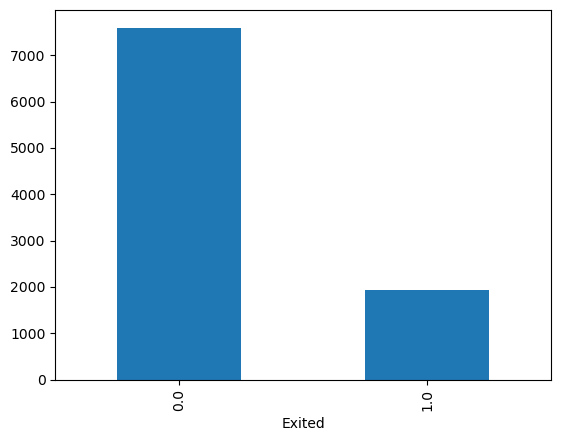

In [83]:
df1["Exited"].value_counts().plot(kind="bar")

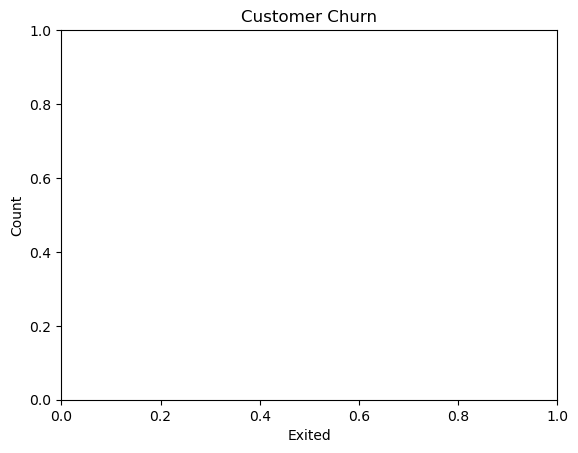

In [84]:
plt.title("Customer Churn")
plt.xlabel("Exited")
plt.ylabel("Count")

plt.show()

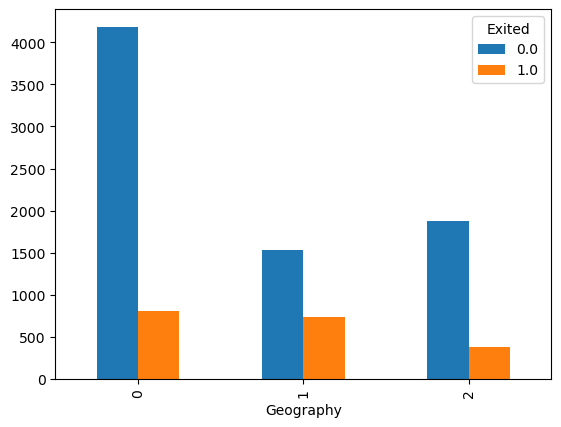

In [85]:
pd.crosstab(df1["Geography"], df1["Exited"]).plot(kind="bar")

plt.show()

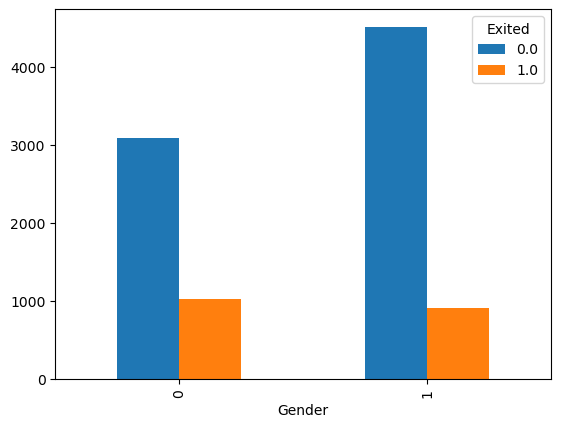

In [86]:
pd.crosstab(df1["Gender"], df1["Exited"]).plot(kind="bar")

plt.show()

In [87]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
ann = Sequential()

In [ ]:
ann.add(Dense(units=16, activation="relu", input_dim=X_train.shape[1]))

ann.add(Dense(units=8, activation="relu"))

ann.add(Dense(units=1, activation="sigmoid"))

In [ ]:
ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = ann.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

In [ ]:
loss, accuracy = ann.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

In [ ]:
y_pred = ann.predict(X_test)

In [ ]:
y_pred = (y_pred > 0.5)

print(y_pred)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
new_customer = [[650,1,1,40,5,60000,2,1,1,70000]]

new_customer = scaler.transform(new_customer)

prediction = ann.predict(new_customer)

if prediction[0][0] > 0.5:
    print("Customer Will Churn")
else:
    print("Customer Will Stay")

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()